# Phân loại bệnh gan từ tập dữ liệu LPD — Notebook chạy được

**Mục tiêu:** Xây dựng một pipeline tiền xử lý dữ liệu và huấn luyện một mô hình **Random Forest** để phân loại _có bệnh gan_ / _không bệnh gan_.

**Nội dung notebook:**

1. Đọc và quan sát dữ liệu
2. Tiền xử lý (sửa giá trị bất hợp lý, tính/điền các chỉ số dựa trên quan hệ y sinh Albumin/TotalProtein/A_G, điền missing bằng median, winsorization)
3. Mã hóa biến phân loại, chia train/test
4. Huấn luyện Random Forest + cross-validation
5. Báo cáo kết quả: accuracy, precision, recall, f1, ROC-AUC, confusion matrix


In [1]:
import os
import warnings
warnings.filterwarnings('once')

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

try:
    from imblearn.over_sampling import SMOTE
    imblearn_available = True
except Exception:
    imblearn_available = False

print('imblearn available:', imblearn_available)


imblearn available: True


In [2]:
DATA_PATH = './data/Liver_Patient_Dataset_(LPD)_train.csv'

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Không tìm thấy file dữ liệu tại {DATA_PATH}. Hãy kiểm tra đường dẫn và upload file vào đúng vị trí.")

df = pd.read_csv(DATA_PATH, encoding='latin1')

# Làm sạch tên cột
df.columns = df.columns.str.strip()               
df.columns = df.columns.str.replace('\xa0', ' ')  
df.columns = df.columns.str.replace(' ', '_')

print('Kích thước dữ liệu:', df.shape)
df.head()


Kích thước dữ liệu: (583, 11)


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [3]:

print('\nSố missing theo cột:')
print(df.isnull().sum())

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('\nCác cột số:', numeric_cols)
print(df[numeric_cols].describe().T)

print(df.info())



Số missing theo cột:
Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64

Các cột số: ['Age', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin', 'Albumin_and_Globulin_Ratio', 'Dataset']
                            count        mean         std   min    25%  \
Age                         583.0   44.746141   16.189833   4.0   33.0   
Total_Bilirubin             583.0    3.298799    6.209522   0.4    0.8   
Direct_Bilirubin            583.0    1.486106    2.808498   0.1    0.2   
Alkaline_Phosphotase        583.0  290.576329  242.937989  63.0  175.5   
Alamine_Aminotransferase    583

In [4]:
data = df.copy()

data.columns = [c.strip() for c in data.columns]

# Map tên cột
col_map = {
    'Dataset': 'Result',                  
    'Gender': 'Sex',                      
    'Alkaline_Phosphotase': 'ALP',
    'Alamine_Aminotransferase': 'ALT',
    'Aspartate_Aminotransferase': 'AST',
    'Total_Protiens': 'Total_Protein',    
    'Albumin_and_Globulin_Ratio': 'A_G_Ratio'
}

# Thực hiện đổi tên
data.rename(columns=col_map, inplace=True)

if 'Result' in data.columns:
    data['Result'] = data['Result'].map({2: 0, 1: 1})
    label_col = 'Result'
    print('Cột nhãn sử dụng:', label_col)
    print('Đã chuyển đổi nhãn: 2 -> 0 (Không bệnh)')

if 'Total_Bilirubin' in data.columns and 'Direct_Bilirubin' in data.columns:
    tb = data['Total_Bilirubin']
    db = data['Direct_Bilirubin']
    bad_direct = data.index[tb.notnull() & db.notnull() & (db > tb)].tolist()

    if len(bad_direct) > 0:
        print(f'Có {len(bad_direct)} dòng Direct > Total — sẽ tự điều chỉnh.')
        data.loc[bad_direct, 'Direct_Bilirubin'] = data.loc[bad_direct, 'Total_Bilirubin']

# Thống kê giá trị thiếu
print('\nSố lượng giá trị thiếu theo cột:')

cols_to_check = [c for c in [
    'Age', 'Sex', 'Total_Bilirubin', 'Direct_Bilirubin', 
    'ALP', 'ALT', 'AST', 'Total_Protein', 'Albumin', 'A_G_Ratio'
] if c in data.columns]

print(data[cols_to_check].isnull().sum())

Cột nhãn sử dụng: Result
Đã chuyển đổi nhãn: 2 -> 0 (Không bệnh)
Có 3 dòng Direct > Total — sẽ tự điều chỉnh.

Số lượng giá trị thiếu theo cột:
Age                 0
Sex                 0
Total_Bilirubin     0
Direct_Bilirubin    0
ALP                 0
ALT                 0
AST                 0
Total_Protein       0
Albumin             0
A_G_Ratio           4
dtype: int64


In [5]:
def fill_ag_albumin_total(df):
    # Công thức: A_G_Ratio = Albumin / (Total_Protein - Albumin)
    mask_ag = df['A_G_Ratio'].isnull() & df['Albumin'].notnull() & df['Total_Protein'].notnull()
    df.loc[mask_ag, 'A_G_Ratio'] = df.loc[mask_ag, 'Albumin'] / (df.loc[mask_ag, 'Total_Protein'] - df.loc[mask_ag, 'Albumin'])

    mask_albumin = df['Albumin'].isnull() & df['A_G_Ratio'].notnull() & df['Total_Protein'].notnull()
    df.loc[mask_albumin, 'Albumin'] = (df.loc[mask_albumin, 'A_G_Ratio'] * df.loc[mask_albumin, 'Total_Protein']) / (1 + df.loc[mask_albumin, 'A_G_Ratio'])

    mask_total = df['Total_Protein'].isnull() & df['Albumin'].notnull() & df['A_G_Ratio'].notnull()
    df.loc[mask_total, 'Total_Protein'] = df.loc[mask_total, 'Albumin'] * (1 + 1.0/df.loc[mask_total, 'A_G_Ratio'])

    return df

data = fill_ag_albumin_total(data)

after_missing = data[['A_G_Ratio','Albumin','Total_Protein']].isnull().sum()
print('Missing sau khi điền bằng công thức:', after_missing)

# Sau khi dùng quan hệ, nếu vẫn missing thì điền bằng median (robust với outliers)
for c in ['Age','Total_Bilirubin','Direct_Bilirubin','ALP','ALT','AST',
          'Total_Protein','Albumin','A_G_Ratio']:
    if c in data.columns:
        med = data[c].median()
        data[c] = data[c].fillna(med)

# Sex: điền bằng mode nếu missing
if 'Sex' in data.columns:
    mode_sex = data['Sex'].mode()
    if len(mode_sex) > 0:
        data['Sex'] = data['Sex'].fillna(mode_sex[0])


print('\nMissing tổng sau điền median/mode:')
print(data.isnull().sum())


Missing sau khi điền bằng công thức: A_G_Ratio        0
Albumin          0
Total_Protein    0
dtype: int64

Missing tổng sau điền median/mode:
Age                 0
Sex                 0
Total_Bilirubin     0
Direct_Bilirubin    0
ALP                 0
ALT                 0
AST                 0
Total_Protein       0
Albumin             0
A_G_Ratio           0
Result              0
dtype: int64


In [6]:
from sklearn.model_selection import train_test_split
# chia tập dữ liệu train và test
X = data.drop(columns=['Result'])
y = data['Result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)



(466, 10) (117, 10)


In [7]:
cols_to_winsor = [
    c for c in [
        'Total_Bilirubin','Direct_Bilirubin','ALP','ALT','AST',
        'Total_Protein','Albumin','A_G_Ratio'
    ] if c in X_train.columns
]

# Lưu ngưỡng từ TRAIN
winsor_limits = {}

for c in cols_to_winsor:
    low = X_train[c].quantile(0.01)
    high = X_train[c].quantile(0.99)
    winsor_limits[c] = (low, high)

    X_train[c] = X_train[c].clip(lower=low, upper=high)
    X_test[c]  = X_test[c].clip(lower=low, upper=high)

print("Hoàn tất winsorization (fit trên TRAIN)")


Hoàn tất winsorization (fit trên TRAIN)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_27264\644044175.py:16: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train[c] = X_train[c].clip(lower=low, upper=high)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_27264\644044175.py:17: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test[c]  = X_tes

In [8]:
#dùng SMOTE, chỉ áp dụng trên train
use_smote = True
if imblearn_available and use_smote:
    from imblearn.over_sampling import SMOTE

    X_train_sm = X_train.copy()

    # Encode tạm thời
    sex_mapping = None
    if 'Sex' in X_train_sm.columns:
        sex_mapping = {'Male': 1, 'Female': 0}
        inv_sex_mapping = {1: 'Male', 0: 'Female'}
        X_train_sm['Sex'] = X_train_sm['Sex'].map(sex_mapping)

    # SMOTE
    sm = SMOTE(random_state=42)
    X_train_sm, y_train_sm = sm.fit_resample(X_train_sm, y_train)

    # Decode lại
    if sex_mapping is not None:
        X_train_sm['Sex'] = X_train_sm['Sex'].round().map(inv_sex_mapping)

    print('After SMOTE, train shape:', X_train_sm.shape)

else:
    X_train_sm, y_train_sm = X_train, y_train


# Chuẩn hóa (standard) trước khi train (không bắt buộc nhưng hữu ích nếu bạn dùng các mô hình khác)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm.select_dtypes(include=[np.number]))
X_test_scaled = scaler.transform(X_test.select_dtypes(include=[np.number]))

# Lưu danh sách feature numeric để mapping lại
numeric_features = X_train_sm.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric features used:', numeric_features)


After SMOTE, train shape: (666, 10)


Numeric features used: ['Age', 'Total_Bilirubin', 'Direct_Bilirubin', 'ALP', 'ALT', 'AST', 'Total_Protein', 'Albumin', 'A_G_Ratio']


CV accuracy (5-fold): [0.76865672 0.7593985  0.7518797  0.78195489 0.78947368]
CV accuracy mean: 0.7702726966670406

--- Kết quả trên tập test ---
Accuracy: 0.717948717948718
Precision: 0.7906976744186046
Recall: 0.8192771084337349
F1-score: 0.8047337278106509
ROC-AUC: 0.771793054571226

Classification report:

              precision    recall  f1-score   support

           0       0.52      0.47      0.49        34
           1       0.79      0.82      0.80        83

    accuracy                           0.72       117
   macro avg       0.65      0.64      0.65       117
weighted avg       0.71      0.72      0.71       117

Confusion matrix:
 [[16 18]
 [15 68]]


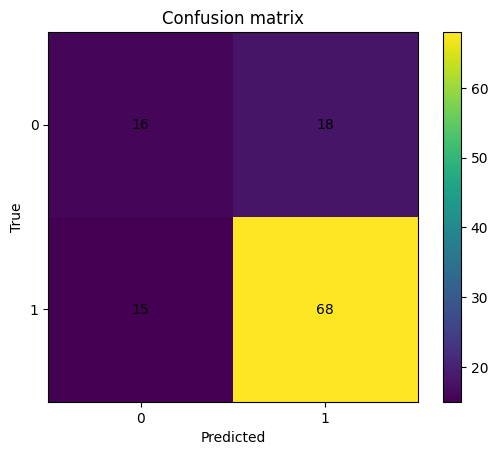

In [ ]:
# Huấn luyện Random Forest trên dữ liệu đã chuẩn hóa
rf = RandomForestClassifier(
    n_estimators=300,        
    criterion='entropy',     # Thử dùng entropy thay vì gini (thường tốt hơn cho dữ liệu y tế)
    max_depth=20,            
    min_samples_split=20,   
    min_samples_leaf=5,      
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1
)
# Cross-validation (Stratified KFold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_train_scaled, y_train_sm, cv=skf, scoring='accuracy')
print('CV accuracy (5-fold):', cv_scores)
print('CV accuracy mean:', cv_scores.mean())

# Fit trên toàn bộ train rồi đánh giá trên test
rf.fit(X_train_scaled, y_train_sm)

y_pred = rf.predict(X_test_scaled)

y_prob = None
try:
    y_prob = rf.predict_proba(X_test_scaled)[:,1]
except Exception:
    pass

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc = roc_auc_score(y_test, y_prob) if y_prob is not None else None

print('\n--- Kết quả trên tập test ---')
print('Accuracy:', acc)
print('Precision:', prec)
print('Recall:', rec)
print('F1-score:', f1)
print('ROC-AUC:', roc)

print('\nClassification report:\n')
print(classification_report(y_test, y_pred, zero_division=0))

# Ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix:\n', cm)

# Vẽ ma trận nhầm lẫn
plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion matrix')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks([0,1])
plt.yticks([0,1])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha='center', va='center')
plt.show()


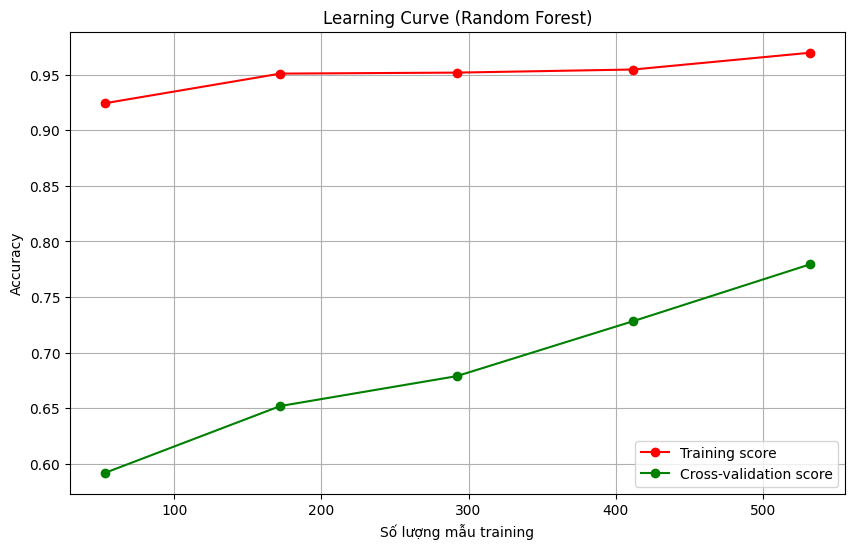

In [10]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, cv=5):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5), # Chia dữ liệu từ 10% đến 100%
        scoring='accuracy'
    )
    
    # Tính trung bình và độ lệch chuẩn
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    
    plt.title(title)
    plt.xlabel("Số lượng mẫu training")
    plt.ylabel("Accuracy")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

# Gọi hàm vẽ (dùng X_train_scaled và y_train_sm của bạn)
plot_learning_curve(rf, "Learning Curve (Random Forest)", X_train_scaled, y_train_sm)

Top 10 feature theo importance:
ALP                 0.165205
AST                 0.136865
Total_Bilirubin     0.121315
Direct_Bilirubin    0.116412
Age                 0.113736
ALT                 0.103971
A_G_Ratio           0.089443
Total_Protein       0.079209
Albumin             0.073843
dtype: float64


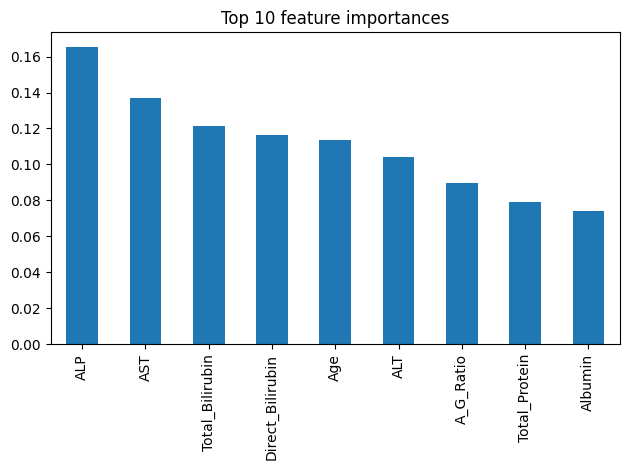

In [11]:
# Giá trị quan trọng của biến (feature importances)
importances = rf.feature_importances_
fi = pd.Series(importances, index=numeric_features).sort_values(ascending=False)
print('Top 10 feature theo importance:')
print(fi.head(10))

# Vẽ biểu đồ nhỏ
plt.figure()
fi.head(10).plot(kind='bar')
plt.title('Top 10 feature importances')
plt.tight_layout()
plt.show()


In [12]:
# Lưu mô hình và scaler để dùng sau này
import joblib
model_path = '/mnt/data/rf_liver_model.joblib'
scaler_path = '/mnt/data/scaler_liver.joblib'
joblib.dump(rf, "rf_liver_model.joblib")
joblib.dump(scaler, "scaler_liver.joblib")
print('Đã lưu model ->', model_path)
print('Đã lưu scaler ->', scaler_path)


Đã lưu model -> /mnt/data/rf_liver_model.joblib
Đã lưu scaler -> /mnt/data/scaler_liver.joblib


## Kết luận (tóm tắt)

- Notebook này thực hiện tiền xử lý theo hướng tận dụng tri thức y-sinh (tính/điền giá trị A/G, Albumin, Total Protein từ mối quan hệ thực tế) và kỹ thuật xử lý ngoại lệ (winsorization).
- Mô hình Random Forest được huấn luyện và đánh giá; kết quả (accuracy, precision, recall, F1, ROC-AUC) được in ở phần trên.
- Bạn có thể thay đổi tham số `use_smote = True` để thử cân bằng lớp bằng SMOTE nếu `imblearn` có sẵn.

Nếu bạn muốn mình điều chỉnh notebook (ví dụ: thêm GridSearchCV để tối ưu tham số, thêm báo cáo hình ảnh chi tiết, hoặc xuất file báo cáo PDF), hãy nói rõ yêu cầu — mình sẽ cập nhật ngay.
